In [1]:
import pandas as pd

df = pd.read_csv("gun_violence_final.csv")

df.head()

,FIPS,year,deaths,population,crude_rate,was_suppressed,yoy_pct_change,spike,svi_unemp_rate,svi_no_hs_diploma,...,RPL_THEME1,RPL_THEME2,RPL_THEME3,RPL_THEME4,RPL_THEMES,svi_poverty_rate,svi_housing_burden,acs_poverty_rate,acs_unemp_rate,acs_median_income
0,1001,2019,5.0,55869.0,8.949507,1,-0.479694,0,4.2,11.3,...,0.3631,0.5810,0.5947,0.3741,0.4354,15.4,22.4,15.185172,3.676644,58731.0
1,1001,2020,5.0,56145.0,8.905513,1,-0.491584,0,2.9,11.3,...,0.3838,0.7362,0.6337,0.4309,0.5130,22.9,23.3,15.211758,2.907252,57982.0
2,1001,2021,12.0,59095.0,20.306286,0,128.019291,1,2.9,11.3,...,0.3838,0.7362,0.6337,0.4309,0.5130,22.9,23.3,13.578474,2.824625,62660.0
3,1001,2022,14.0,59759.0,23.427434,0,15.370349,0,2.9,11.3,...,0.3838,0.7362,0.6337,0.4309,0.5130,22.9,23.3,11.373969,2.768472,68315.0
4,1001,2023,12.0,60342.0,19.886646,0,-15.113851,0,2.9,11.3,...,0.3838,0.7362,0.6337,0.4309,0.5130,22.9,23.3,10.684306,2.541559,69841.0


In [2]:
median_rate = df["crude_rate"].median()
print(median_rate)

20.64068692206077


In [3]:
#finding what a high level of gun violence is 
df["violence_level"] = df["crude_rate"].apply(
    lambda x: "high" if x >= median_rate else "low"
)
df[["crude_rate", "violence_level"]].head()

,crude_rate,violence_level
0,8.949507,low
1,8.905513,low
2,20.306286,low
3,23.427434,high
4,19.886646,low


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

df = pd.read_csv("gun_violence_with_levels.csv")

print(f"Shape: {df.shape}")
print(f"Counties (unique FIPS): {df['FIPS'].nunique()}")
print(f"Years covered: {sorted(df['year'].unique())}")
print(f"County-years per year:")
print(df["year"].value_counts().sort_index())

Shape: (13328, 33)
Counties (unique FIPS): 3027
Years covered: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
County-years per year:
year
2019    2494
2020    2651
2021    2714
2022    2734
2023    2735
Name: count, dtype: int64


In [5]:
# Missing values
missing = df.isna().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values")

# Suppression flag — CDC suppresses death counts when too low
print(f"\nRows with suppressed death counts: {df['was_suppressed'].sum()} ({df['was_suppressed'].mean()*100:.1f}%)")

# Duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"Duplicate FIPS-year pairs: {df.duplicated(subset=['FIPS','year']).sum()}")

# Basic descriptive stats on key columns
print("\nDescriptive stats — key numeric features:")
df[["deaths", "population", "crude_rate", "acs_poverty_rate",
    "acs_unemp_rate", "acs_median_income"]].describe().round(2)

Missing values per column:
No missing values

Rows with suppressed death counts: 8879 (66.6%)

Duplicate rows: 0
Duplicate FIPS-year pairs: 0

Descriptive stats — key numeric features:


,deaths,population,crude_rate,acs_poverty_rate,acs_unemp_rate,acs_median_income
count,13328.00,13328.00,13328.00,13328.00,13328.00,13328.00
mean,17.83,122609.64,30.71,14.70,5.24,59808.70
std,47.80,358362.07,38.06,5.93,2.33,16905.95
min,5.00,565.00,1.43,1.72,0.00,21504.00
25%,5.00,15769.75,13.16,10.46,3.76,48649.75
50%,5.00,33583.00,20.64,13.85,4.90,57241.50
75%,13.00,87323.25,34.54,17.93,6.27,67646.50
max,1190.00,10039107.00,884.96,59.02,32.42,178707.00


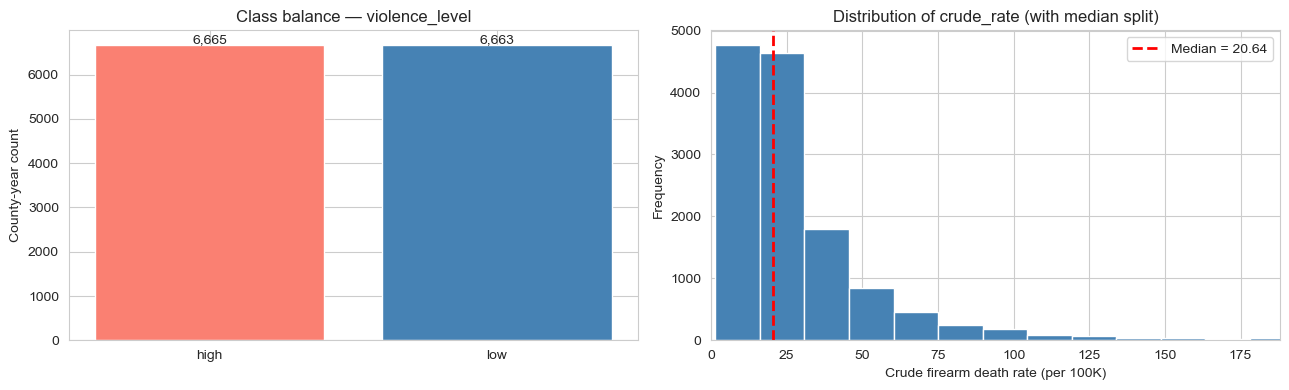

Median: 20.64  |  Mean: 30.71  |  Max: 884.96


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Class balance
counts = df["violence_level"].value_counts()
axes[0].bar(counts.index, counts.values, color=["salmon", "steelblue"])
axes[0].set_title("Class balance — violence_level")
axes[0].set_ylabel("County-year count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f"{v:,}", ha="center")

# Distribution of crude_rate with the median threshold marked
median_rate = df["crude_rate"].median()
axes[1].hist(df["crude_rate"], bins=60, color="steelblue", edgecolor="white")
axes[1].axvline(median_rate, color="red", linestyle="--", linewidth=2,
                label=f"Median = {median_rate:.2f}")
axes[1].set_xlabel("Crude firearm death rate (per 100K)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of crude_rate (with median split)")
axes[1].legend()
axes[1].set_xlim(0, df["crude_rate"].quantile(0.99))  # trim long tail for readability

plt.tight_layout()
plt.show()

print(f"Median: {median_rate:.2f}  |  Mean: {df['crude_rate'].mean():.2f}  |  Max: {df['crude_rate'].max():.2f}")

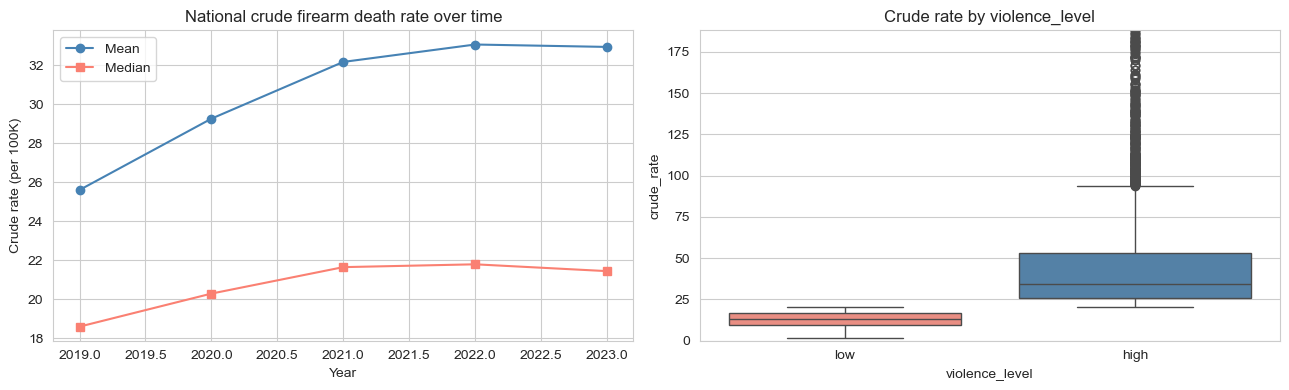

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Trend over time
yearly = df.groupby("year")["crude_rate"].agg(["mean", "median"]).reset_index()
axes[0].plot(yearly["year"], yearly["mean"], marker="o", label="Mean", color="steelblue")
axes[0].plot(yearly["year"], yearly["median"], marker="s", label="Median", color="salmon")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Crude rate (per 100K)")
axes[0].set_title("National crude firearm death rate over time")
axes[0].legend()

# Boxplot by violence_level
sns.boxplot(data=df, x="violence_level", y="crude_rate",
            order=["low", "high"], palette=["salmon", "steelblue"], ax=axes[1])
axes[1].set_title("Crude rate by violence_level")
axes[1].set_ylim(0, df["crude_rate"].quantile(0.99))

plt.tight_layout()
plt.show()

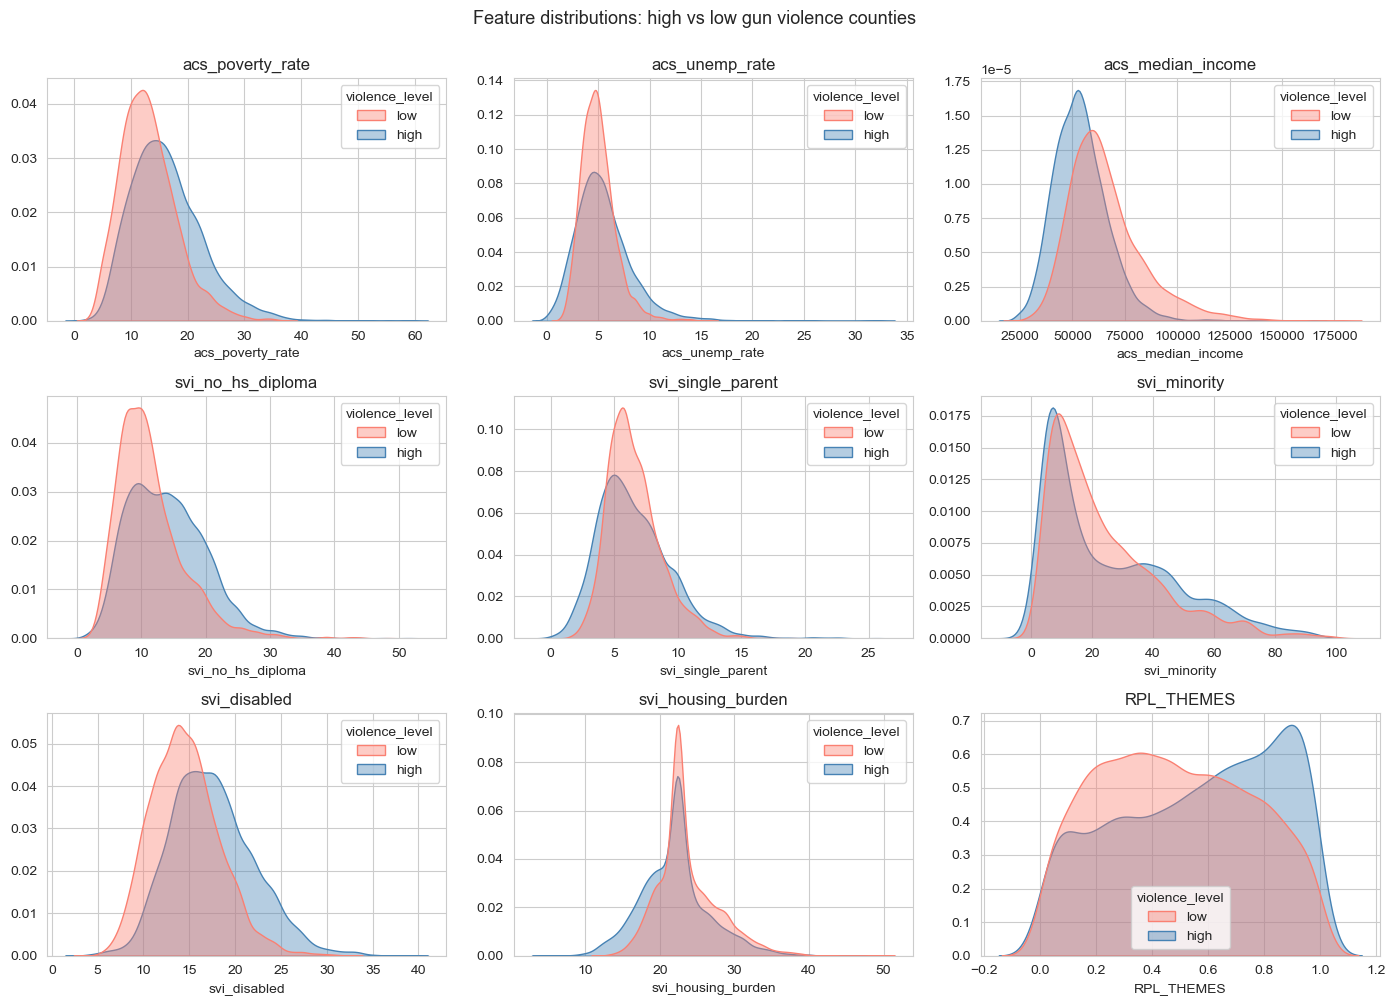

In [8]:
# Pick the most policy-relevant features to compare across classes
key_features = [
    "acs_poverty_rate", "acs_unemp_rate", "acs_median_income",
    "svi_no_hs_diploma", "svi_single_parent", "svi_minority",
    "svi_disabled", "svi_housing_burden", "RPL_THEMES"
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, feat in zip(axes.flat, key_features):
    sns.kdeplot(data=df, x=feat, hue="violence_level",
                hue_order=["low", "high"], palette=["salmon", "steelblue"],
                fill=True, alpha=0.4, ax=ax)
    ax.set_title(feat)
    ax.set_ylabel("")

plt.suptitle("Feature distributions: high vs low gun violence counties", y=1.00, fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
# Compare means across all SVI and ACS features for high vs low counties
feature_cols = [c for c in df.columns if c.startswith("svi_")
                or c.startswith("acs_") or c.startswith("RPL_")]

comparison = df.groupby("violence_level")[feature_cols].mean().T
comparison["difference"] = comparison["high"] - comparison["low"]
comparison["pct_diff"] = (comparison["difference"] / comparison["low"] * 100).round(1)
comparison = comparison.sort_values("pct_diff", key=abs, ascending=False)

print("Feature means by violence_level (sorted by % difference):")
print(comparison.round(3).to_string())

Feature means by violence_level (sorted by % difference):
violence_level            high        low  difference  pct_diff
svi_mobile_homes        15.749      9.624       6.125      63.6
svi_multi_unit           3.229      7.125      -3.896     -54.7
svi_limited_english      1.303      1.971      -0.669     -33.9
svi_poverty_rate        25.665     20.303       5.362      26.4
RPL_THEME1               0.580      0.459       0.120      26.2
RPL_THEME2               0.565      0.450       0.115      25.6
acs_poverty_rate        16.318     13.091       3.226      24.6
svi_uninsured           10.509      8.489       2.019      23.8
svi_no_hs_diploma       13.978     11.319       2.659      23.5
svi_disabled            17.497     14.531       2.967      20.4
acs_median_income    53841.883  65777.301  -11935.418     -18.1
RPL_THEMES               0.564      0.483       0.082      16.9
svi_age65_plus          19.827     17.480       2.346      13.4
svi_group_quarters       3.642      3.212     

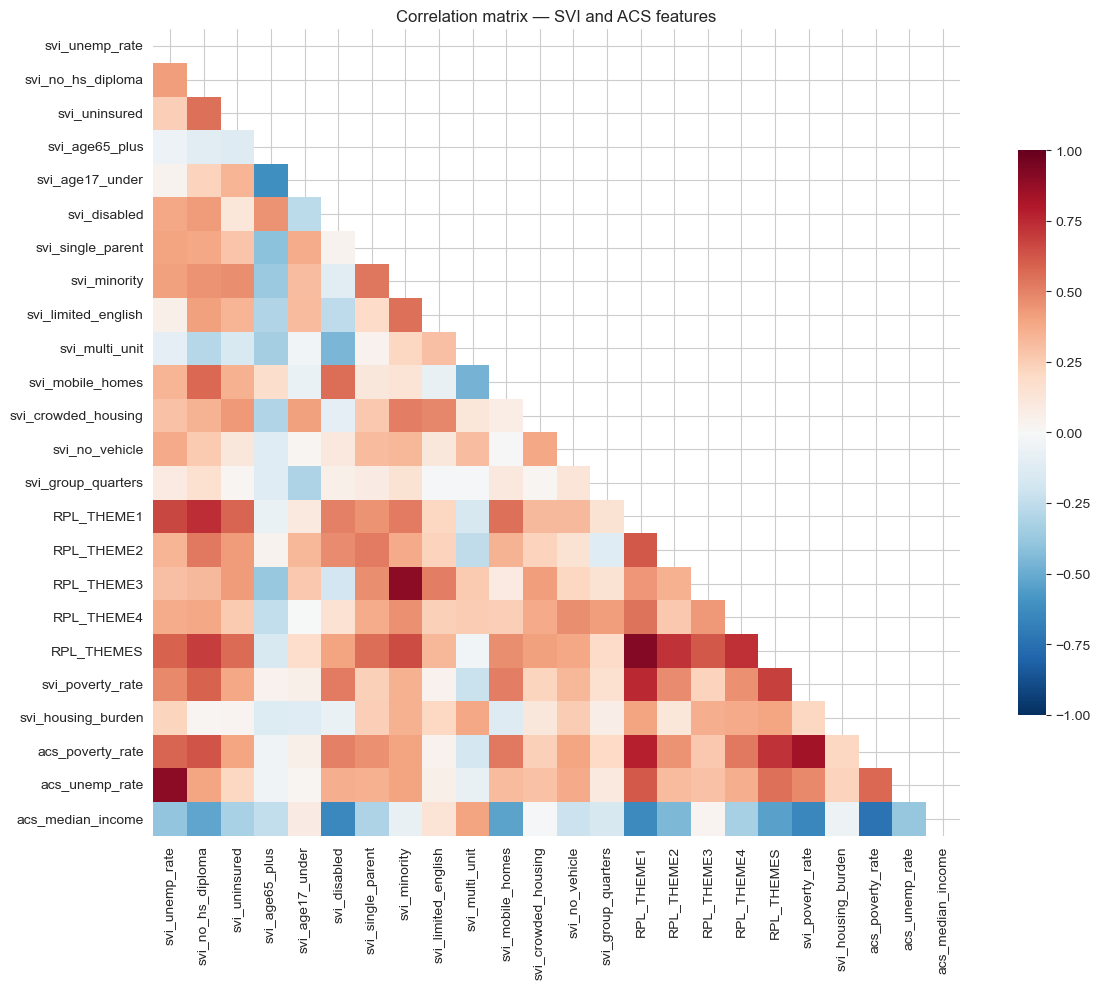


Feature pairs with |correlation| > 0.8 (4 pairs):
  svi_unemp_rate            <-> acs_unemp_rate            r = 0.898
  svi_minority              <-> RPL_THEME3                r = 0.898
  RPL_THEME1                <-> RPL_THEMES                r = 0.916
  svi_poverty_rate          <-> acs_poverty_rate          r = 0.836


In [10]:
fig, ax = plt.subplots(figsize=(13, 10))
corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": 0.7}, ax=ax,
            xticklabels=True, yticklabels=True)
ax.set_title("Correlation matrix — SVI and ACS features")
plt.tight_layout()
plt.show()

# Flag highly correlated pairs (likely multicollinearity issue for LR)
high_corr = (corr.abs() > 0.8) & (corr.abs() < 1.0)
pairs = []
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        if high_corr.iloc[i, j]:
            pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

print(f"\nFeature pairs with |correlation| > 0.8 ({len(pairs)} pairs):")
for f1, f2, c in pairs:
    print(f"  {f1:<25} <-> {f2:<25} r = {c:.3f}")

Features ranked by absolute correlation with violence_level=high:
            feature  correlation_with_high
  acs_median_income                -0.3530
       svi_disabled                 0.3344
   svi_mobile_homes                 0.3215
     svi_multi_unit                -0.3214
   svi_poverty_rate                 0.3085
   acs_poverty_rate                 0.2721
     svi_age65_plus                 0.2601
  svi_no_hs_diploma                 0.2306
         RPL_THEME1                 0.2129
      svi_uninsured                 0.2112
         RPL_THEME2                 0.2012
 svi_housing_burden                -0.1866
         RPL_THEMES                 0.1452
svi_limited_english                -0.1296
     svi_unemp_rate                 0.1177
     acs_unemp_rate                 0.1078
       svi_minority                 0.0599
 svi_group_quarters                 0.0519
         RPL_THEME4                -0.0396
     svi_no_vehicle                 0.0369
         RPL_THEME3            

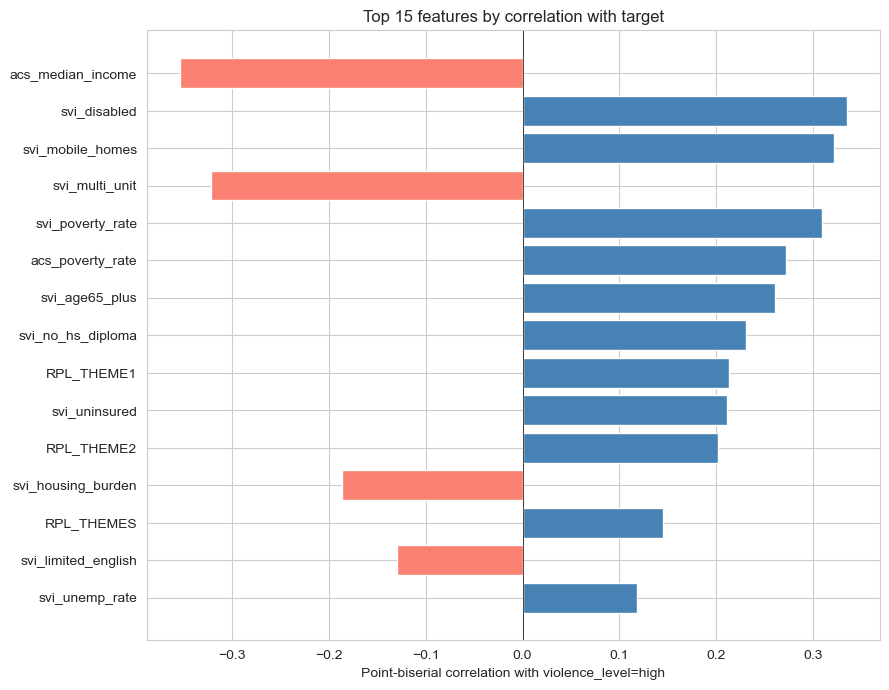

In [11]:
# Point-biserial correlation between each feature and binary target
y_binary = (df["violence_level"] == "high").astype(int)

corrs_with_target = pd.DataFrame({
    "feature": feature_cols,
    "correlation_with_high": [df[f].corr(y_binary) for f in feature_cols]
}).sort_values("correlation_with_high", key=abs, ascending=False)

print("Features ranked by absolute correlation with violence_level=high:")
print(corrs_with_target.round(4).to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(9, 7))
top15 = corrs_with_target.head(15).iloc[::-1]
colors = ["steelblue" if c > 0 else "salmon" for c in top15["correlation_with_high"]]
ax.barh(top15["feature"], top15["correlation_with_high"], color=colors)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Point-biserial correlation with violence_level=high")
ax.set_title("Top 15 features by correlation with target")
plt.tight_layout()
plt.show()

In [12]:
## Modeling — Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay
)
import joblib
import shap

In [14]:
# Drop columns that leak the target or aren't features
leak_cols = ["deaths", "crude_rate", "yoy_pct_change", "spike", "was_suppressed"]
id_cols = ["FIPS", "year"]
target_col = "violence_level"
redundant_cols = ["RPL_THEMES"]

feature_cols_model = [c for c in df.columns
                      if c not in leak_cols + id_cols + [target_col] + redundant_cols]

X = df[feature_cols_model].copy()
y = (df[target_col] == "high").astype(int)
groups = df["FIPS"]

print(f"Features used in model ({len(feature_cols_model)}):")
for c in feature_cols_model:
    print(f"  {c}")

Features used in model (24):
  population
  svi_unemp_rate
  svi_no_hs_diploma
  svi_uninsured
  svi_age65_plus
  svi_age17_under
  svi_disabled
  svi_single_parent
  svi_minority
  svi_limited_english
  svi_multi_unit
  svi_mobile_homes
  svi_crowded_housing
  svi_no_vehicle
  svi_group_quarters
  RPL_THEME1
  RPL_THEME2
  RPL_THEME3
  RPL_THEME4
  svi_poverty_rate
  svi_housing_burden
  acs_poverty_rate
  acs_unemp_rate
  acs_median_income


In [15]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train: {X_train.shape[0]} rows ({df.iloc[train_idx]['FIPS'].nunique()} counties)")
print(f"Test:  {X_test.shape[0]} rows ({df.iloc[test_idx]['FIPS'].nunique()} counties)")

overlap = set(df.iloc[train_idx]['FIPS']) & set(df.iloc[test_idx]['FIPS'])
print(f"County overlap between train/test: {len(overlap)} (should be 0)")

Train: 10681 rows (2421 counties)
Test:  2647 rows (606 counties)
County overlap between train/test: 0 (should be 0)


In [16]:
# Random Forest doesn't need feature scaling — trees split on raw values
rf_baseline = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    n_jobs=-1,
    random_state=42
)
rf_baseline.fit(X_train, y_train)

y_pred_base = rf_baseline.predict(X_test)
y_proba_base = rf_baseline.predict_proba(X_test)[:, 1]

print("=== Baseline Random Forest (n_estimators=200, no max_depth) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_base):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_base):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_base):.4f}")

=== Baseline Random Forest (n_estimators=200, no max_depth) ===
Accuracy:  0.9116
Precision: 0.9764
Recall:    0.8379
F1:        0.9018
ROC-AUC:   0.9615


In [17]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

grid_rf = RandomizedSearchCV(
    RandomForestClassifier(n_jobs=-1, random_state=42),
    param_dist,
    n_iter=20,        # try 20 random combos instead of all 108
    cv=3,             # 3 folds instead of 5
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=2
)
grid_rf.fit(X_train, y_train)

print(f"\nBest params: {grid_rf.best_params_}")
print(f"Best CV ROC-AUC: {grid_rf.best_score_:.4f}")

best_rf = grid_rf.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10}
Best CV ROC-AUC: 0.9481


In [18]:
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

print("=== Tuned Random Forest ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1:        {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["low", "high"]))

print("Confusion matrix:")
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm,
                   index=["actual_low","actual_high"],
                   columns=["pred_low","pred_high"]))

=== Tuned Random Forest ===
Accuracy:  0.9090
Precision: 0.9736
Recall:    0.8348
F1:        0.8989
ROC-AUC:   0.9607

Classification report:
              precision    recall  f1-score   support

         low       0.86      0.98      0.92      1364
        high       0.97      0.83      0.90      1283

    accuracy                           0.91      2647
   macro avg       0.92      0.91      0.91      2647
weighted avg       0.92      0.91      0.91      2647

Confusion matrix:
             pred_low  pred_high
actual_low       1335         29
actual_high       212       1071


Top features by Random Forest impurity importance:
           feature  importance
        population    0.520644
    svi_multi_unit    0.072782
  svi_mobile_homes    0.032234
 acs_median_income    0.031657
      svi_disabled    0.030768
    svi_age65_plus    0.028559
  svi_poverty_rate    0.027020
svi_housing_burden    0.021508
 svi_no_hs_diploma    0.020719
  acs_poverty_rate    0.020055


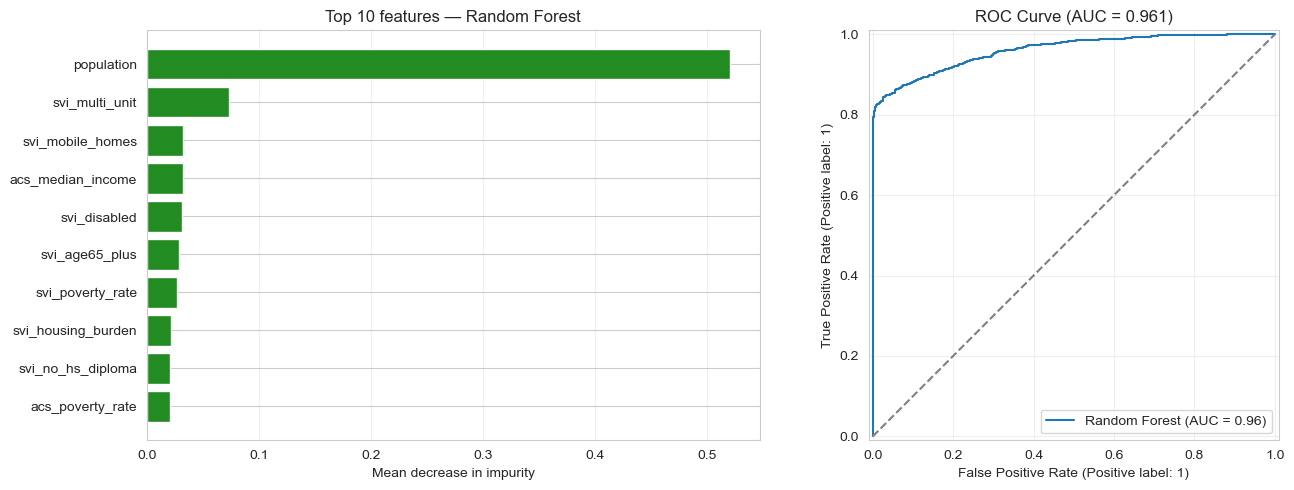

In [19]:
rf_importances = pd.DataFrame({
    "feature": feature_cols_model,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

print("Top features by Random Forest impurity importance:")
print(rf_importances.head(10).to_string(index=False))

# Visualize alongside ROC curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_n = 10
top_feats = rf_importances.head(top_n).iloc[::-1]
axes[0].barh(top_feats["feature"], top_feats["importance"], color="forestgreen")
axes[0].set_xlabel("Mean decrease in impurity")
axes[0].set_title(f"Top {top_n} features — Random Forest")
axes[0].grid(axis="x", alpha=0.3)

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name="Random Forest")
axes[1].plot([0,1],[0,1], linestyle="--", color="gray")
axes[1].set_title(f"ROC Curve (AUC = {roc_auc_score(y_test, y_proba):.3f})")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# TreeExplainer is exact and fast for tree-based models
explainer_rf = shap.TreeExplainer(best_rf)
shap_values_rf = explainer_rf.shap_values(X_test)

# For binary classification, TreeExplainer can return either:
#   - a list of two arrays (one per class)
#   - a 3D array with shape (n_samples, n_features, n_classes)
# We want the values for class 1 ("high")
if isinstance(shap_values_rf, list):
    shap_values_rf = shap_values_rf[1]
elif shap_values_rf.ndim == 3:
    shap_values_rf = shap_values_rf[:, :, 1]

print(f"SHAP values shape: {shap_values_rf.shape}")
print("(rows = test samples, columns = features)")

SHAP values shape: (2647, 24)
(rows = test samples, columns = features)


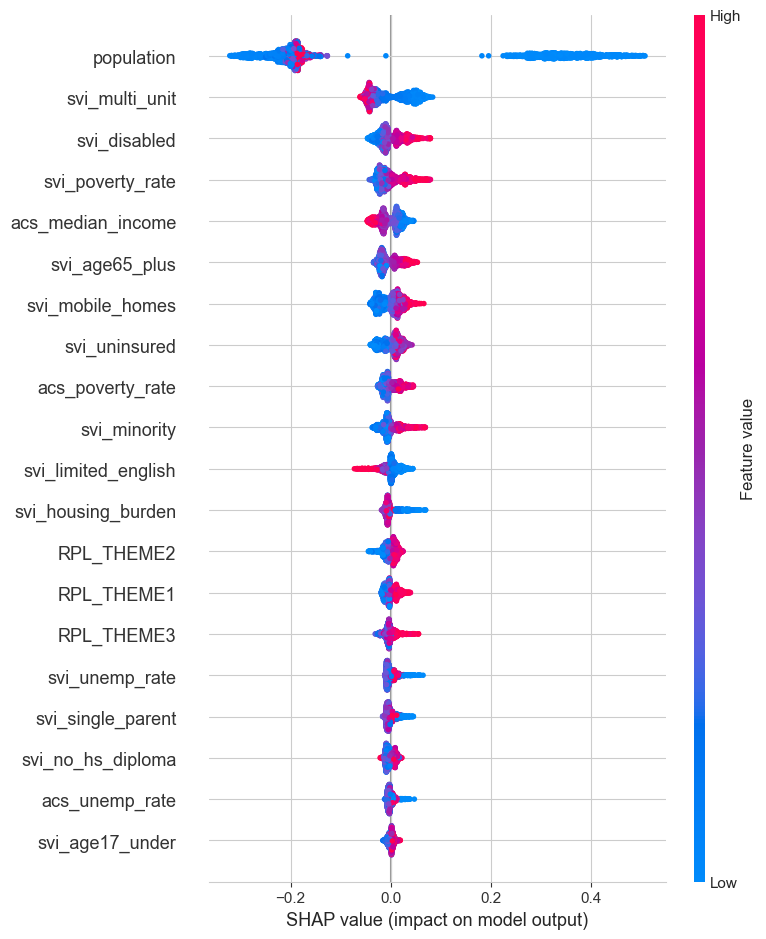

In [21]:
shap.summary_plot(
    shap_values_rf,
    X_test,
    feature_names=feature_cols_model,
    plot_type="dot",
    show=True
)

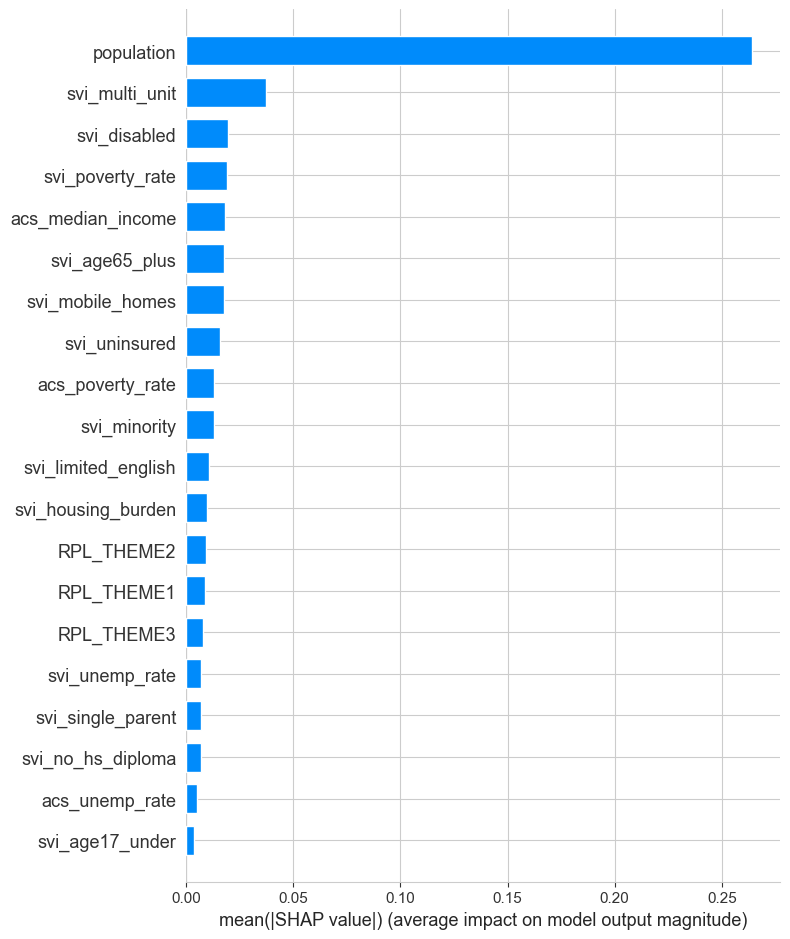

In [22]:
shap.summary_plot(
    shap_values_rf,
    X_test,
    feature_names=feature_cols_model,
    plot_type="bar",
    show=True
)

In [23]:
mean_abs_shap_rf = np.abs(shap_values_rf).mean(axis=0)
shap_importance_rf = pd.DataFrame({
    "feature": feature_cols_model,
    "mean_abs_shap": mean_abs_shap_rf
}).sort_values("mean_abs_shap", ascending=False)

# Merge with native importance for direct comparison
comparison_rf = shap_importance_rf.merge(rf_importances, on="feature")
comparison_rf["shap_rank"] = comparison_rf["mean_abs_shap"].rank(ascending=False).astype(int)
comparison_rf["native_rank"] = comparison_rf["importance"].rank(ascending=False).astype(int)
comparison_rf = comparison_rf.sort_values("shap_rank")

print("Random Forest feature importance — SHAP vs native:")
print(comparison_rf[["feature","mean_abs_shap","importance","shap_rank","native_rank"]]
      .head(15).round(4).to_string(index=False))

# Sanity check — do the two methods agree on the top 5?
top5_shap = set(comparison_rf.nsmallest(5, "shap_rank")["feature"])
top5_native = set(comparison_rf.nsmallest(5, "native_rank")["feature"])
print(f"\nTop 5 by SHAP:   {top5_shap}")
print(f"Top 5 by native: {top5_native}")
print(f"Overlap: {top5_shap & top5_native}")

Random Forest feature importance — SHAP vs native:
            feature  mean_abs_shap  importance  shap_rank  native_rank
         population         0.2640      0.5206          1            1
     svi_multi_unit         0.0375      0.0728          2            2
       svi_disabled         0.0196      0.0308          3            5
   svi_poverty_rate         0.0190      0.0270          4            7
  acs_median_income         0.0182      0.0317          5            4
     svi_age65_plus         0.0178      0.0286          6            6
   svi_mobile_homes         0.0177      0.0322          7            3
      svi_uninsured         0.0158      0.0177          8           13
   acs_poverty_rate         0.0129      0.0201          9           10
       svi_minority         0.0129      0.0176         10           14
svi_limited_english         0.0106      0.0196         11           11
 svi_housing_burden         0.0100      0.0215         12            8
         RPL_THEME2       

County FIPS: 1001
Actual:    low
Predicted: low (prob_high = 0.268)


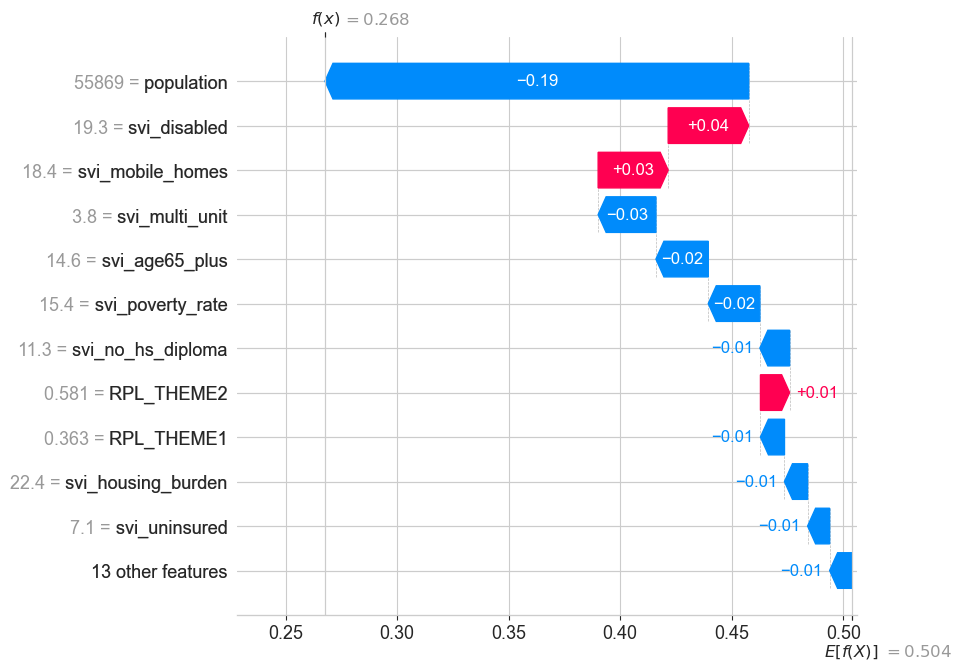

In [24]:
idx = 0
sample_features = X_test.iloc[idx]
sample_pred = best_rf.predict(X_test.iloc[[idx]])[0]
sample_proba = best_rf.predict_proba(X_test.iloc[[idx]])[0, 1]
sample_actual = y_test.iloc[idx]
sample_fips = df.iloc[test_idx[idx]]["FIPS"]

print(f"County FIPS: {sample_fips}")
print(f"Actual:    {'high' if sample_actual == 1 else 'low'}")
print(f"Predicted: {'high' if sample_pred == 1 else 'low'} (prob_high = {sample_proba:.3f})")

# Waterfall plot showing how each feature pushed prediction toward high or low
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_rf[idx],
        base_values=explainer_rf.expected_value[1] if isinstance(explainer_rf.expected_value, np.ndarray)
                    else explainer_rf.expected_value,
        data=X_test.iloc[idx].values,
        feature_names=feature_cols_model
    ),
    max_display=12
)

In [25]:
joblib.dump(best_rf, "rf_jake.pkl")
print("Saved: rf_jake.pkl")

# Sanity check reload
loaded = joblib.load("rf_jake.pkl")
sample = X_test.iloc[[0]]
print(f"Reload test — pred: {loaded.predict(sample)[0]}, prob: {loaded.predict_proba(sample)[0,1]:.3f}")

Saved: rf_jake.pkl
Reload test — pred: 0, prob: 0.268


In [26]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)

y_dummy_pred = dummy.predict(X_test)
y_dummy_proba = dummy.predict_proba(X_test)[:, 1]

print("=== Dummy Majority Baseline ===")
print(f"Accuracy:  {accuracy_score(y_test, y_dummy_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_dummy_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_dummy_pred, zero_division=0):.4f}")
print(f"F1:        {f1_score(y_test, y_dummy_pred, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_dummy_proba):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_dummy_pred))

=== Dummy Majority Baseline ===
Accuracy:  0.4847
Precision: 0.4847
Recall:    1.0000
F1:        0.6529
ROC-AUC:   0.5000

Confusion Matrix:
[[   0 1364]
 [   0 1283]]


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Remove population from features
feature_cols_no_pop = [col for col in feature_cols_model if col != "population"]

X_no_pop = df[feature_cols_no_pop].copy()
y_no_pop = (df["violence_level"] == "high").astype(int)
groups_no_pop = df["FIPS"]

# Same group split logic as the main model
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx_np, test_idx_np = next(gss.split(X_no_pop, y_no_pop, groups_no_pop))

X_train_np = X_no_pop.iloc[train_idx_np]
X_test_np = X_no_pop.iloc[test_idx_np]
y_train_np = y_no_pop.iloc[train_idx_np]
y_test_np = y_no_pop.iloc[test_idx_np]

rf_no_pop = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=4,
    max_features="log2",
    n_jobs=-1,
    random_state=42
)

rf_no_pop.fit(X_train_np, y_train_np)

y_pred_np = rf_no_pop.predict(X_test_np)
y_proba_np = rf_no_pop.predict_proba(X_test_np)[:, 1]

print("=== Random Forest Without Population ===")
print(f"Accuracy:  {accuracy_score(y_test_np, y_pred_np):.4f}")
print(f"Precision: {precision_score(y_test_np, y_pred_np):.4f}")
print(f"Recall:    {recall_score(y_test_np, y_pred_np):.4f}")
print(f"F1:        {f1_score(y_test_np, y_pred_np):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_np, y_proba_np):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_np, y_pred_np))

=== Random Forest Without Population ===
Accuracy:  0.7552
Precision: 0.7340
Recall:    0.7763
F1:        0.7545
ROC-AUC:   0.8423

Confusion Matrix:
[[1003  361]
 [ 287  996]]


In [29]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

model = best_rf  # fixed: was rf_best

y_train_pred = model.predict(X_train)
y_train_proba = model.predict_proba(X_train)[:, 1]

y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)[:, 1]

print("=== Train vs Test Performance ===")
print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")

print(f"Train F1:       {f1_score(y_train, y_train_pred):.4f}")
print(f"Test F1:        {f1_score(y_test, y_test_pred):.4f}")

print(f"Train ROC-AUC:  {roc_auc_score(y_train, y_train_proba):.4f}")
print(f"Test ROC-AUC:   {roc_auc_score(y_test, y_test_proba):.4f}")

=== Train vs Test Performance ===
Train Accuracy: 0.9338
Test Accuracy:  0.9090
Train F1:       0.9305
Test F1:        0.8989
Train ROC-AUC:  0.9883
Test ROC-AUC:   0.9607


In [30]:
# Fix: remove population (deaths/population*100k = crude_rate — perfect leakage)
feature_cols_fixed = [col for col in feature_cols_model if col != "population"]

X_fixed = df[feature_cols_fixed].copy()
y_fixed = (df["violence_level"] == "high").astype(int)

gss_fixed = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx_f, test_idx_f = next(gss_fixed.split(X_fixed, y_fixed, groups))

X_train_f, X_test_f = X_fixed.iloc[train_idx_f], X_fixed.iloc[test_idx_f]
y_train_f, y_test_f = y_fixed.iloc[train_idx_f], y_fixed.iloc[test_idx_f]

# Use same best params found during tuning but on clean features
best_rf_fixed = RandomForestClassifier(
    **grid_rf.best_params_,
    n_jobs=-1,
    random_state=42
)
best_rf_fixed.fit(X_train_f, y_train_f)

y_pred_f   = best_rf_fixed.predict(X_test_f)
y_proba_f  = best_rf_fixed.predict_proba(X_test_f)[:,1]

train_pred_f = best_rf_fixed.predict(X_train_f)

print("=== FIXED Random Forest (population removed) ===")
print(f"Train Accuracy: {accuracy_score(y_train_f, train_pred_f):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test_f, y_pred_f):.4f}")
print(f"Overfit Gap:    {accuracy_score(y_train_f, train_pred_f) - accuracy_score(y_test_f, y_pred_f):.4f}")
print(f"Recall:         {recall_score(y_test_f, y_pred_f):.4f}")
print(f"F1:             {f1_score(y_test_f, y_pred_f):.4f}")
print(f"ROC-AUC:        {roc_auc_score(y_test_f, y_proba_f):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_f, y_pred_f, target_names=["low","high"]))

=== FIXED Random Forest (population removed) ===
Train Accuracy: 0.9013
Test Accuracy:  0.7552
Overfit Gap:    0.1461
Recall:         0.7763
F1:             0.7545
ROC-AUC:        0.8423

Classification Report:
              precision    recall  f1-score   support

         low       0.78      0.74      0.76      1364
        high       0.73      0.78      0.75      1283

    accuracy                           0.76      2647
   macro avg       0.76      0.76      0.76      2647
weighted avg       0.76      0.76      0.76      2647



In [31]:
comparison_table = pd.DataFrame({
    "Model":        ["Original (leaky)", "Fixed (no population)"],
    "Train Acc":    [best_rf.score(X_train, y_train), best_rf_fixed.score(X_train_f, y_train_f)],
    "Test Acc":     [accuracy_score(y_test, y_pred), accuracy_score(y_test_f, y_pred_f)],
    "Gap":          [best_rf.score(X_train, y_train) - accuracy_score(y_test, y_pred),
                     best_rf_fixed.score(X_train_f, y_train_f) - accuracy_score(y_test_f, y_pred_f)],
    "F1":           [f1_score(y_test, y_pred), f1_score(y_test_f, y_pred_f)],
    "ROC-AUC":      [roc_auc_score(y_test, y_proba), roc_auc_score(y_test_f, y_proba_f)]
}).round(4)

print(comparison_table.to_string(index=False))
print("\n→ Drop in performance after fix reflects honest prediction from socioeconomic features only.")

                Model  Train Acc  Test Acc    Gap     F1  ROC-AUC
     Original (leaky)     0.9338    0.9090 0.0249 0.8989   0.9607
Fixed (no population)     0.9013    0.7552 0.1461 0.7545   0.8423

→ Drop in performance after fix reflects honest prediction from socioeconomic features only.


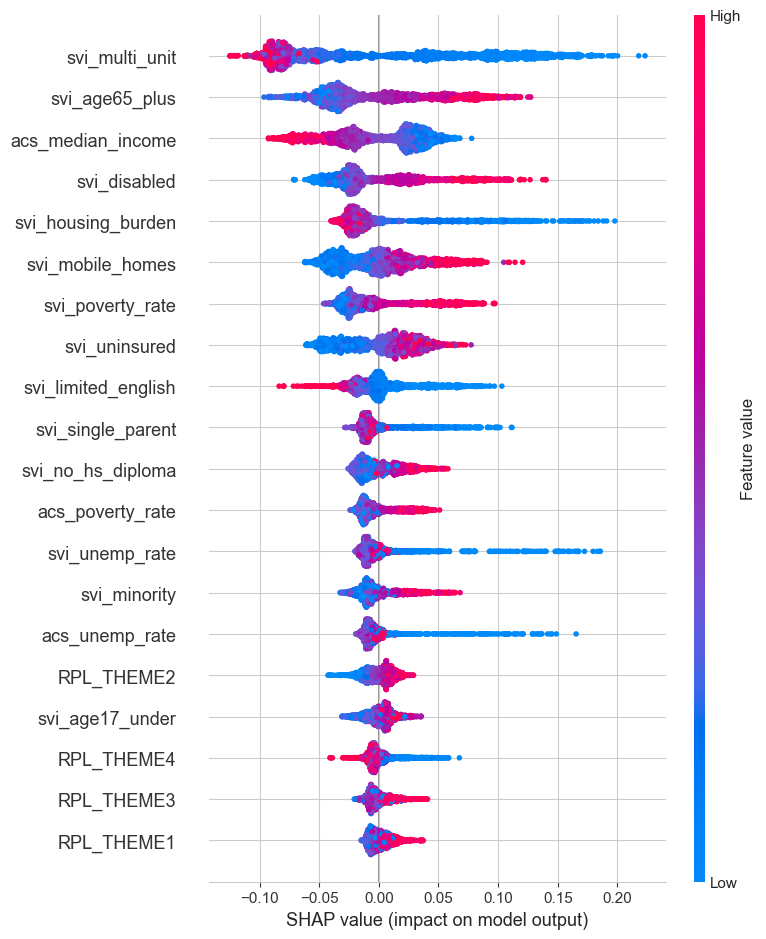

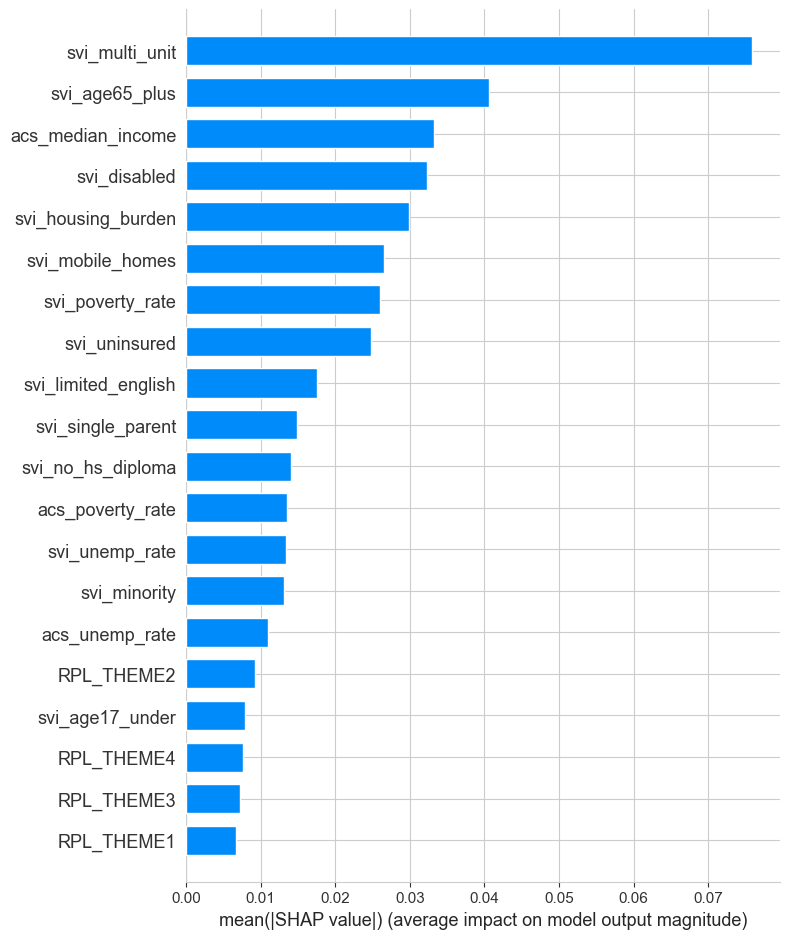

Saved: rf_jake_fixed.pkl


In [32]:
explainer_fixed = shap.TreeExplainer(best_rf_fixed)
shap_values_fixed = explainer_fixed.shap_values(X_test_f)

if isinstance(shap_values_fixed, list):
    shap_values_fixed = shap_values_fixed[1]
elif shap_values_fixed.ndim == 3:
    shap_values_fixed = shap_values_fixed[:, :, 1]

shap.summary_plot(
    shap_values_fixed,
    X_test_f,
    feature_names=feature_cols_fixed,
    plot_type="dot"
)

shap.summary_plot(
    shap_values_fixed,
    X_test_f,
    feature_names=feature_cols_fixed,
    plot_type="bar"
)

# Save fixed model
joblib.dump(best_rf_fixed, "rf_jake_fixed.pkl")
print("Saved: rf_jake_fixed.pkl")